In [1]:
%reload_ext autoreload
%autoreload 2

import FinanceDataReader as fdr
from src.bq import BigQueryStockData, BigQueryIndexData
from src.backtest import Backtest
from src.pattern import Pattern, Bollinger, High, GoldenCross, Trending, Disparity

### BigQuery 수정주가 조회
`src.bq.BigqueryData`를 사용해 특정 종목/기간의 수정 OHLC를 가져옵니다.


In [2]:
# tickers = ['005930']#, '000660']
# flds = ['close', 'market_cap']
# start = '2010-01-01'
# end = '2020-12-31'

stock = BigQueryStockData(market=['KOSPI'], start='2000-01-01')

In [3]:
daily = stock.get_data();daily

,ticker,name,market,open,high,low,close,volume,amount,shares_outstanding,market_cap,rank,is_tradable,dept
date,,,,,,,,,,,,,,
2000-01-04,000010,조흥은행,KOSPI,3930.0,4255.0,3850.0,4050.0,785510,3.217298e+09,679078115,2.750266e+12,28,True,None
2000-01-04,009190,대양금속,KOSPI,1610.0,1860.0,1610.0,1860.0,82130,1.459177e+08,27282000,5.074452e+10,508,True,None
2000-01-04,009200,신무림제지,KOSPI,7100.0,7400.0,7100.0,7300.0,46070,3.325017e+08,12999000,9.489270e+10,341,True,None
2000-01-04,009270,신 원,KOSPI,1430.0,1585.0,1410.0,1585.0,624320,9.160702e+08,34329807,5.441274e+10,489,True,None
2000-01-04,009275,신 원(1우),KOSPI,1200.0,1495.0,1200.0,1390.0,3780,4.949950e+06,362963,5.045186e+08,1332,True,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-06,006880,신송홀딩스,KOSPI,6740.0,7200.0,6710.0,6980.0,564142,3.969915e+09,11828858,8.256543e+10,1673,True,None
2026-03-06,006890,태경케미컬,KOSPI,8370.0,10450.0,8140.0,8950.0,5227874,5.013882e+10,11600000,1.038200e+11,1501,True,None
2026-03-06,006980,우성,KOSPI,20900.0,21600.0,20300.0,21400.0,6359,1.340342e+08,3090000,6.612600e+10,1853,True,None


In [5]:
adj_daily = stock.get_adj_data(); adj_daily

,ticker,name,market,open,high,low,close,volume,amount,shares_outstanding,market_cap,rank,is_tradable,dept
date,,,,,,,,,,,,,,
2000-01-04,000010,조흥은행,KOSPI,3930.000000,4255.000000,3850.000000,4050.000000,785510.0,3.217298e+09,679078115.0,2.750266e+12,28,True,None
2000-01-04,009190,대양금속,KOSPI,102560.469220,118486.007919,102560.469220,118486.007919,1289.281348,1.459177e+08,428274.366663,5.074452e+10,508,True,None
2000-01-04,009200,신무림제지,KOSPI,3550.000000,3700.000000,3550.000000,3650.000000,92140.0,3.325017e+08,25998000.0,9.489270e+10,341,True,None
2000-01-04,009270,신 원,KOSPI,5830.897959,6462.918367,5749.346939,6462.918367,153111.511512,9.160702e+08,8419221.936937,5.441274e+10,489,True,None
2000-01-04,009275,신 원(1우),KOSPI,2431.168831,3028.831169,2431.168831,2816.103896,1865.769231,4.949950e+06,179154.814103,5.045186e+08,1332,True,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-06,006880,신송홀딩스,KOSPI,6740.000000,7200.000000,6710.000000,6980.000000,564142.0,3.969915e+09,11828858.0,8.256543e+10,1673,True,None
2026-03-06,006890,태경케미컬,KOSPI,8370.000000,10450.000000,8140.000000,8950.000000,5227874.0,5.013882e+10,11600000.0,1.038200e+11,1501,True,None
2026-03-06,006980,우성,KOSPI,20900.000000,21600.000000,20300.000000,21400.000000,6359.0,1.340342e+08,3090000.0,6.612600e+10,1853,True,None


In [16]:
daily[daily.ticker=='005930'].loc['2018-04-25':'2018-05-10']

,ticker,name,close,market_cap
date,,,,
2018-04-25,005930,삼성전자,2520000.0,3.235340e+14
2018-04-26,005930,삼성전자,2607000.0,3.347036e+14
2018-04-27,005930,삼성전자,2650000.0,3.402242e+14
2018-05-04,005930,삼성전자,51900.0,3.331630e+14
2018-05-08,005930,삼성전자,52600.0,3.376565e+14
2018-05-09,005930,삼성전자,50900.0,3.267436e+14
2018-05-10,005930,삼성전자,51600.0,3.312372e+14


In [17]:
adj_daily[adj_daily.ticker=='005930'].loc['2018-04-25':'2018-05-10']

,ticker,name,close,market_cap
date,,,,
2018-04-25,005930,삼성전자,50400.0,3.235340e+14
2018-04-26,005930,삼성전자,52140.0,3.347036e+14
2018-04-27,005930,삼성전자,53000.0,3.402242e+14
2018-05-04,005930,삼성전자,51900.0,3.331630e+14
2018-05-08,005930,삼성전자,52600.0,3.376565e+14
2018-05-09,005930,삼성전자,50900.0,3.267436e+14
2018-05-10,005930,삼성전자,51600.0,3.312372e+14


<Axes: xlabel='date'>

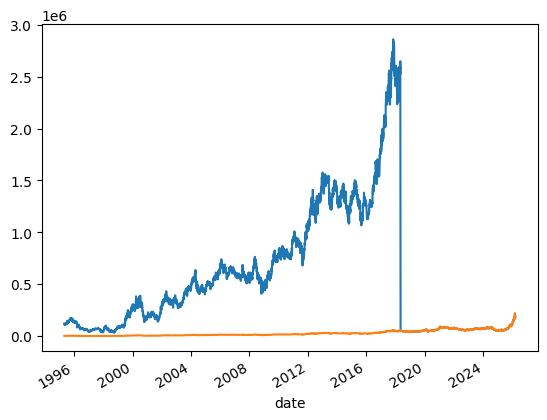

In [18]:
fld = 'close'
ticker = '005930'
daily[daily.ticker==ticker][fld].plot()
adj_daily[adj_daily.ticker==ticker][fld].plot()

<Axes: title={'center': '005930 adjusted close comparison'}, xlabel='date', ylabel='price'>

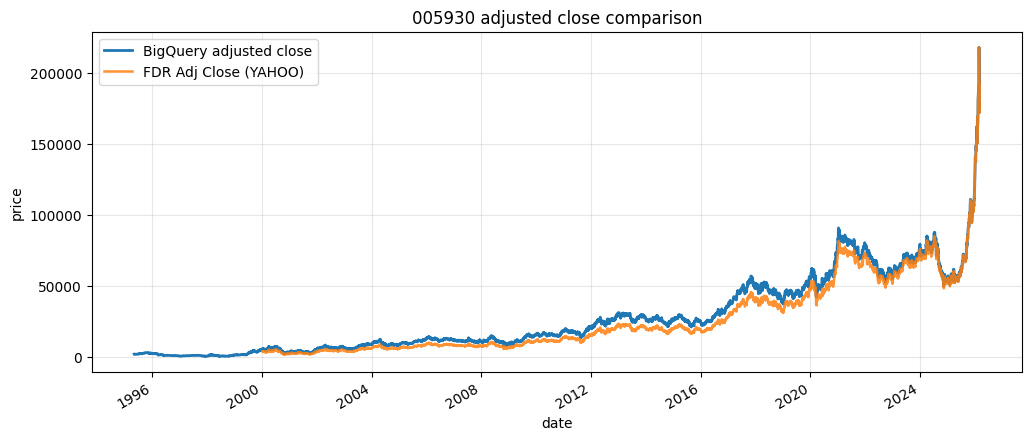

In [19]:
stock.plot_with_fdr(ticker='005930')

In [4]:
stock.get_adjust_factors()

,ticker,ratio
date,,
2000-01-04,000100,0.903642
2000-01-04,010150,0.949043
2000-01-04,010040,0.956124
2000-01-04,009290,0.991935
2000-01-04,009280,0.954316
...,...,...
2026-01-14,000300,2.116935
2026-01-16,100250,0.963981
2026-01-28,091810,0.952918


In [25]:
idx = BigQueryIndexData('코스피', flds=['close', 'market_cap'])

In [26]:
idx.get_data()

,close,market_cap
date,,
1995-01-03,1013.57,<NA>
1995-01-04,997.01,<NA>
1995-01-05,976.06,<NA>
1995-01-06,975.32,<NA>
1995-01-07,988.80,<NA>
...,...,...
2026-02-27,6244.13,5146373107791624
2026-03-03,5791.91,4769433446422237
2026-03-04,5093.54,4194946818672921
